In [6]:
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

try:
    import lal
    import lalsimulation as lalsim
except ImportError:
    sys.exit("LALSuite not available.")

from ripplegw.waveforms.IMRPhenomXAS_NRTidalv3 import gen_IMRPhenomXAS_NRTidalv3_hphc
from ripplegw.conversions import ms_to_Mc_eta, lambdas_to_lambda_tildes
from ripplegw.waveforms.NRTidalv3_utils import _get_merger_frequency

from ripplegw.constants import MSUN

In [7]:
F_L   = 20.0
F_U   = 4096.0
T     = 32.0
DF    = 1.0 / T
F_REF = 20.0
IOTA  = 0.4       # off-axis so hp amplitude doesn't vanish

DIST = 100

fs    = jnp.arange(F_L, F_U, DF)
f_np  = np.asarray(fs)

In [8]:
def get_lal_hp(m1, m2, chi1, chi2, l1, l2):
    m1_kg = m1 * lal.MSUN_SI
    m2_kg = m2 * lal.MSUN_SI
    dist  = DIST * 1e6 * lal.PC_SI
    laldict = lal.CreateDict()
    lalsim.SimInspiralWaveformParamsInsertTidalLambda1(laldict, l1)
    lalsim.SimInspiralWaveformParamsInsertTidalLambda2(laldict, l2)
    q1 = lalsim.SimUniversalRelationQuadMonVSlambda2Tidal(l1)
    q2 = lalsim.SimUniversalRelationQuadMonVSlambda2Tidal(l2)
    lalsim.SimInspiralWaveformParamsInsertdQuadMon1(laldict, q1 - 1)
    lalsim.SimInspiralWaveformParamsInsertdQuadMon2(laldict, q2 - 1)
    approx = lalsim.SimInspiralGetApproximantFromString("IMRPhenomXAS_NRTidalv3")
    hp_lal, _ = lalsim.SimInspiralChooseFDWaveform(
        m1_kg, m2_kg, 0.0, 0.0, chi1, 0.0, 0.0, chi2,
        dist, IOTA, 0.0, 0, 0, 0,
        DF, F_L, F_U, F_REF, laldict, approx,
    )
    freqs_lal = np.arange(len(hp_lal.data.data)) * DF
    mask = (freqs_lal > F_L) & (freqs_lal < F_U)
    return np.asarray(hp_lal.data.data[mask])


def get_ripple_hp(m1, m2, chi1, chi2, l1, l2):
    Mc, eta = ms_to_Mc_eta(jnp.array([m1, m2]))
    lt, dlt = lambdas_to_lambda_tildes(jnp.array([l1, l2, m1, m2]))
    params  = jnp.array([Mc, eta, chi1, chi2, lt, dlt, DIST, 0.0, 0.0, IOTA])
    hp, _   = gen_IMRPhenomXAS_NRTidalv3_hphc(fs, params, F_REF, use_lambda_tildes=True)
    return np.asarray(hp)

In [4]:
m1 = 1.4
m2 = 1.0
chi1 = 0.2
chi2 = 0.1
l1 = 400
l2 = 350

hp_lal    = get_lal_hp(m1, m2, chi1, chi2, l1, l2)
hp_ripple = get_ripple_hp(m1, m2, chi1, chi2, l1, l2)

In [11]:
f_merger_ripple = _get_merger_frequency(jnp.array([m1, m2, chi1, chi2, l1, l2]))
f_merger_lal = lalsim.SimNRTunedTidesMergerFrequency_v3(
    (m1 + m2), 
    l1,
    l2,
    m1/m2,
    chi1,
    chi2,
)

print(f_merger_ripple)
print(f_merger_lal)

1860.1214326230252
1860.1214326230252


In [ ]:
n = min(len(hp_lal), len(hp_ripple))
fs = fs[:n]
lal_phase = np.unwrap(np.angle(hp_lal[:n]))
ripple_phase = np.unwrap(np.angle(hp_ripple[:n]))

dphase = lal_phase - ripple_phase

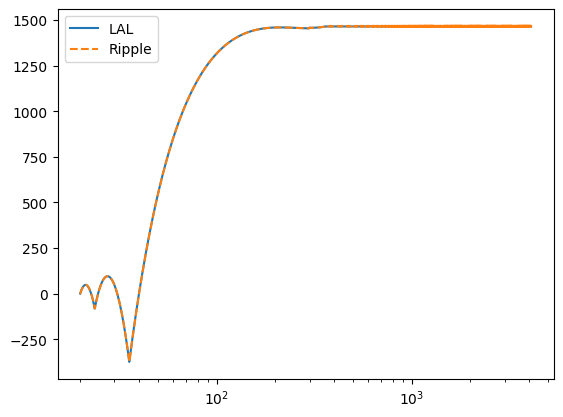

In [ ]:
plt.plot(fs, lal_phase, label='LAL')
plt.plot(fs, ripple_phase, label='Ripple', ls='--')
plt.xscale('log')
plt.legend()
plt.show()

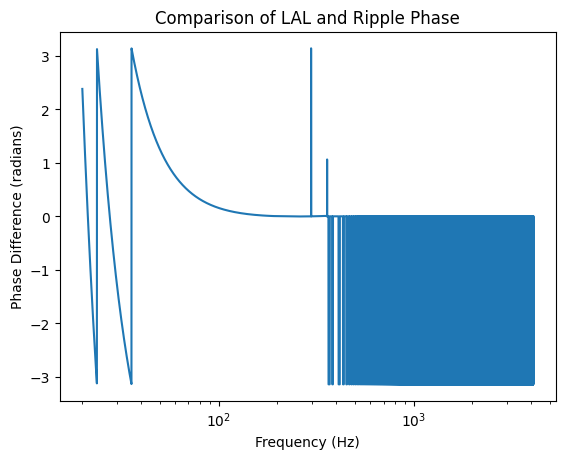

In [ ]:
plt.plot(fs, dphase)
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase Difference (radians)')
plt.title('Comparison of LAL and Ripple Phase')
plt.show()